Found 2172 refitted t2m BNN files


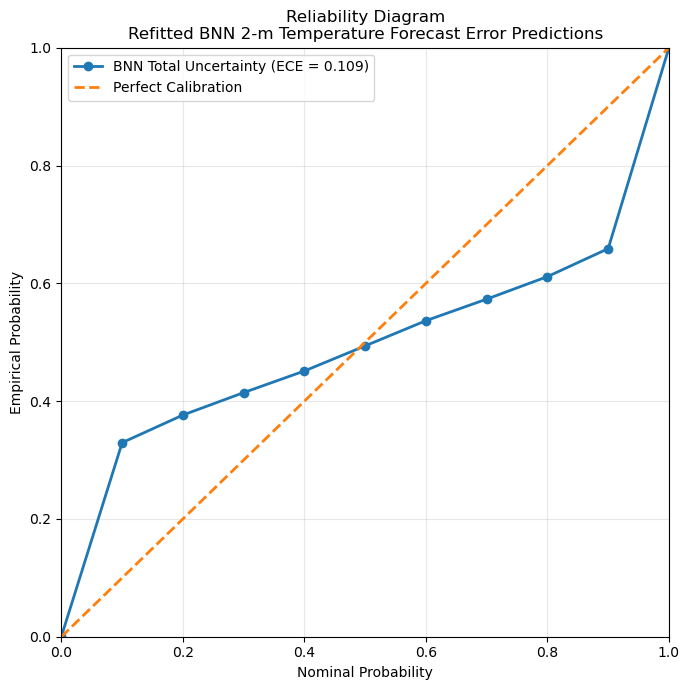

Loaded files: 2172
Skipped files: 0
Errored files: 0
Rows dropped due to NaNs: 0
Total samples: 47,439,339
ECE: 0.1089


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from glob import glob
import os
import re

base_dir = "/home/aevans/nwp_bias/src/machine_learning/data/bnn_hybrid_compare"

files = glob(os.path.join(base_dir, "*", "refitted_*_u_total_*_bnn_epi_output.parquet"))

print(f"Found {len(files)} refitted t2m BNN files")

dfs = []
skipped = 0
errors = 0
rows_dropped = 0

required_cols = [
    "target_error",
    "Model forecast",
    "Model alea std",
    "Model epi std",
    "valid_time",
]

for fp in files:
    try:
        df = pd.read_parquet(fp)

        if df is None or not hasattr(df, "columns"):
            errors += 1
            continue

        if not all(col in df.columns for col in required_cols):
            skipped += 1
            continue

        before = len(df)

        df = df.dropna(
            subset=[
                "target_error",
                "Model forecast",
                "Model alea std",
                "Model epi std",
            ]
        )

        rows_dropped += before - len(df)

        if df.empty:
            skipped += 1
            continue

        fname = os.path.basename(fp)

        match = re.search(
            r"refitted_(.*?)_u_total_(\d+)_bnn_epi_output\.parquet$", fname
        )

        if match is None:
            skipped += 1
            continue

        station = match.group(1)
        forecast_hour = int(match.group(2))

        temp = pd.DataFrame(
            {
                "station": station,
                "forecast_hour": forecast_hour,
                "valid_time": df["valid_time"],
                "y_true": df["target_error"],
                "mu": df["Model forecast"],
                "sigma_epi": df["Model epi std"],
                "sigma_alea": df["Model alea std"],
            }
        )

        dfs.append(temp)

    except Exception:
        errors += 1
        continue

if len(dfs) == 0:
    raise ValueError(
        "No valid files were loaded. Check file paths, columns, or filename pattern."
    )

master = pd.concat(dfs, ignore_index=True)

master["sigma_total"] = np.sqrt(master["sigma_epi"] ** 2 + master["sigma_alea"] ** 2)

master = master.dropna(
    subset=[
        "y_true",
        "mu",
        "sigma_total",
    ]
)

master["sigma_total"] = np.clip(master["sigma_total"], 1e-6, None)

pit = norm.cdf(master["y_true"], loc=master["mu"], scale=master["sigma_total"])

n_bins = 10
nominal = np.linspace(0, 1, n_bins + 1)

empirical = np.array([np.mean(pit <= p) for p in nominal])

ece = np.mean(np.abs(empirical - nominal))

fig, ax = plt.subplots(figsize=(7, 7))

ax.plot(
    nominal,
    empirical,
    marker="o",
    linewidth=2,
    label=f"BNN Total Uncertainty (ECE = {ece:.3f})",
)

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=2, label="Perfect Calibration")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.set_xlabel("Nominal Probability")
ax.set_ylabel("Empirical Probability")

ax.set_title(
    "Reliability Diagram\n" "Refitted BNN 2-m Temperature Forecast Error Predictions"
)

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()

# plt.savefig(
#     "refitted_bnn_t2m_all_stations_all_fh_reliability_diagram.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

print(f"Loaded files: {len(dfs)}")
print(f"Skipped files: {skipped}")
print(f"Errored files: {errors}")
print(f"Rows dropped due to NaNs: {rows_dropped:,}")
print(f"Total samples: {len(master):,}")
print(f"ECE: {ece:.4f}")

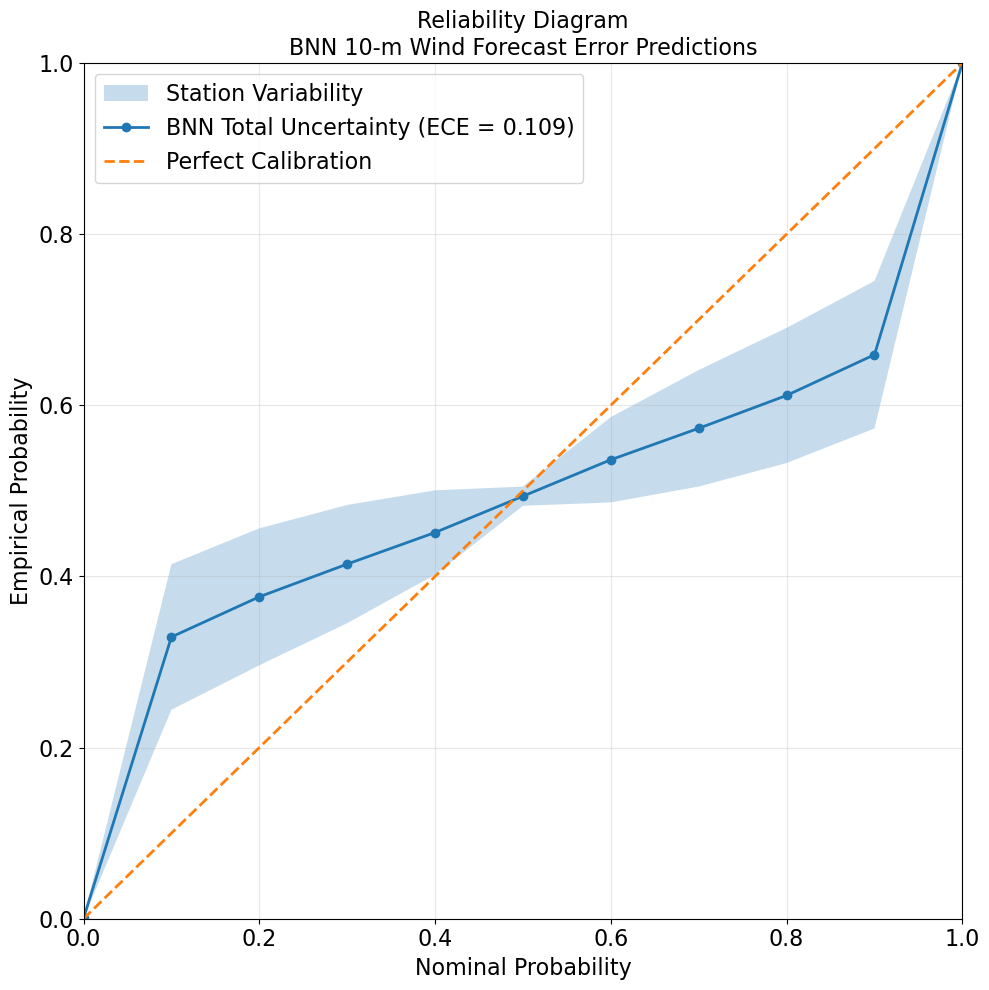

In [2]:
pit = norm.cdf(master["y_true"], loc=master["mu"], scale=master["sigma_total"])

master = master.copy()
master["pit"] = pit

n_bins = 10
nominal = np.linspace(0, 1, n_bins + 1)

# calibration curve for each station
station_curves = []

for station, g in master.groupby("station"):
    curve = [np.mean(g["pit"] <= p) for p in nominal]
    station_curves.append(curve)

station_curves = np.array(station_curves)

empirical_mean = np.nanmean(station_curves, axis=0)
empirical_std = np.nanstd(station_curves, axis=0)

ece = np.mean(np.abs(empirical_mean - nominal))

FS = 16

fig, ax = plt.subplots(figsize=(10, 10))

ax.fill_between(
    nominal,
    empirical_mean - empirical_std,
    empirical_mean + empirical_std,
    alpha=0.25,
    label="Station Variability",
)

ax.plot(
    nominal,
    empirical_mean,
    marker="o",
    linewidth=2,
    label=f"BNN Total Uncertainty (ECE = {ece:.3f})",
)

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=2, label="Perfect Calibration")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.set_xlabel("Nominal Probability", fontsize=FS)
ax.set_ylabel("Empirical Probability", fontsize=FS)

ax.set_title(
    "Reliability Diagram\n" "BNN 10-m Wind Forecast Error Predictions", fontsize=FS
)

ax.tick_params(axis="both", labelsize=FS)
ax.legend(fontsize=FS)

ax.grid(True, alpha=0.3)

plt.tight_layout()

# plt.savefig(
#     "refitted_bnn_t2m_station_spread_reliability_diagram.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

In [3]:
# By forecast hour
ece_by_fh = (
    master.assign(pit=pit)
    .groupby("forecast_hour")
    .apply(
        lambda g: np.mean(
            [abs(np.mean(g["pit"] <= p) - p) for p in np.linspace(0, 1, 11)]
        )
    )
)

print(ece_by_fh)

: 

: 